# Fraud Detection – Baseline Modeling (v1)

**Dataset:** IEEE-CIS Fraud Detection  
**Phase:** Phase 1 – Baseline Modeling & Financial Validation  
**Author:** Bruno Martins  

**Reference:** Cost structure and primary metric are defined in `docs/03_metrics_and_cost_modeling.md`.

---

## 0. Objective & Context

This notebook implements the first statistical baseline for the fraud detection system.

**Goal:** Validate that statistical modeling reduces Expected Monetary Loss and quantify financial impact vs an approve-all baseline.

**Scope:** Temporal split, logistic regression baseline, cost-based threshold optimization, operational metrics (Recall, Precision, FPR), calibration and interpretability checks.

**Outcome:** A reproducible baseline with Expected Loss Reduction quantified and threshold chosen by cost minimization; results documented for `docs/05_modeling_strategy.md`.

The objective is not to maximize AUC, but to align model evaluation with business impact (Expected Monetary Loss).

In [1]:
# 1. Imports and global configuration

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw")

RANDOM_STATE = 42
C_FP = 5.0  # cost of false positive (fixed operational cost)

DATA_PATH

WindowsPath('../data/raw')

**Modeling assumptions and hyperparameter choices**

- **Cost:** C_FP = 5 (fixed); C_FN = TransactionAmt per transaction (see `docs/03_metrics_and_cost_modeling.md`).
- **Split:** Temporal 80/20 by `TransactionDT` (train = past, validation = future); no shuffle.
- **Features:** Numeric columns only; missing values filled with 0; StandardScaler applied.
- **Model:** Logistic Regression, L2 penalty, C=1.0, `class_weight="balanced"`, solver=lbfgs, max_iter=1000.
- **Reproducibility:** RANDOM_STATE=42; DATA_PATH and C_FP set above.

---
## 1. Executive Summary

**Key findings (run full notebook to refresh):**

• Temporal train/validation split (80/20 by TransactionDT); no future leakage.  
• Optimal threshold T* selected by minimizing Expected Monetary Loss on validation.  
• Expected Loss Reduction vs approve-all baseline and relative savings % reported in Section 4.  
• Recall and FPR at T* reported in Section 5; operational constraints checked.

**Conclusion:** The baseline establishes a cost-sensitive reference. Exact figures (T*, loss, savings, Recall, FPR) are in the Summary table at the end of this notebook.

---
## 2. Data Loading and Temporal Split Strategy

**Goal:** Load the IEEE-CIS training data, define a temporal train/validation split by `TransactionDT`, and document split rationale and leakage prevention.

In [2]:
# Load a working sample of the training data
train_tr = pd.read_csv(DATA_PATH / "train_transaction.csv")
train_id = pd.read_csv(DATA_PATH / "train_identity.csv")

train_tr.shape, train_id.shape

((590540, 394), (144233, 41))

In [3]:
# Merge identity (left join) to get a flat table
train_full = train_tr.merge(train_id, on="TransactionID", how="left")

# Basic temporal split based on TransactionDT
min_dt = train_full["TransactionDT"].min()
max_dt = train_full["TransactionDT"].max()

min_dt, max_dt

(np.int64(86400), np.int64(15811131))

In [4]:
# Define temporal split: use older 80% of time for training, newest 20% for validation

quantile_split = 0.8
cutoff = train_full["TransactionDT"].quantile(quantile_split)

train_mask = train_full["TransactionDT"] < cutoff
val_mask = train_full["TransactionDT"] >= cutoff

X_train_raw = train_full.loc[train_mask].copy()
X_val_raw = train_full.loc[val_mask].copy()

y_train = X_train_raw["isFraud"].astype(int)
y_val = X_val_raw["isFraud"].astype(int)

cutoff, y_train.mean(), y_val.mean()

(np.float64(12192853.600000001),
 np.float64(0.03513521522674162),
 np.float64(0.034409184813899145))

**Split rationale:** We split by `TransactionDT` so that training uses only past transactions and validation uses future ones, avoiding leakage.

**Conclusion:** Temporal 80/20 split is applied; no shuffle; validation is strictly future. Documented for reproducibility.

---
## 3. Baseline Model: Logistic Regression

**Goal:** Implement a logistic regression baseline with simple preprocessing (impute, scale), class weighting for imbalance, and interpretable coefficients.

In [5]:
# Select a simple numeric feature set for the baseline

# For the first baseline we only use transaction-level numeric features
numeric_cols = [
    col for col in X_train_raw.columns
    if X_train_raw[col].dtype != "O"  # non-object
    and col not in ["isFraud", "TransactionID", "TransactionDT"]
]

len(numeric_cols), numeric_cols[:10]

(400,
 ['TransactionAmt',
  'card1',
  'card2',
  'card3',
  'card5',
  'addr1',
  'addr2',
  'dist1',
  'dist2',
  'C1'])

In [6]:
# Build baseline pipeline: impute missing with 0 and scale numeric features

X_train = X_train_raw[numeric_cols].fillna(0.0)
X_val = X_val_raw[numeric_cols].fillna(0.0)

baseline_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        (
            "clf",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",  # handle imbalance
                max_iter=1000,
                solver="lbfgs",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_pipeline

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [7]:
# Fit baseline model
baseline_pipeline.fit(X_train, y_train)

# Predict probabilities on validation set
val_proba = baseline_pipeline.predict_proba(X_val)[:, 1]

roc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)

roc, pr_auc

(0.8247517422823682, 0.1761253501980234)

**Conclusion:** ROC-AUC and PR-AUC are diagnostic only; primary objective is Expected Monetary Loss. Baseline is fitted and produces probabilities for threshold sweep.

### 3.1 Probability calibration

Check whether predicted probabilities are well calibrated (fraction of positives in bins of predicted probability).

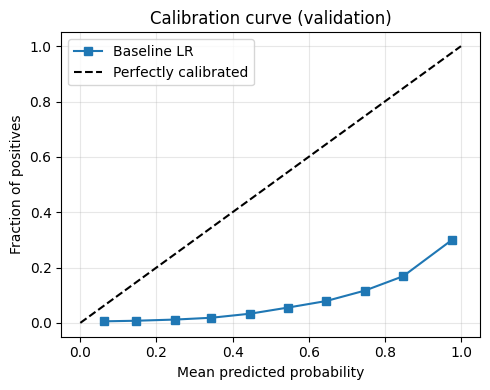

In [8]:
# Calibration curve on validation set
frac_pos, mean_pred = calibration_curve(y_val, val_proba, n_bins=10)
plt.figure(figsize=(5, 4))
plt.plot(mean_pred, frac_pos, "s-", label="Baseline LR")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve (validation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion:** If the curve is close to the diagonal, probabilities are reasonably calibrated. If not, consider recalibration (e.g. Platt scaling or isotonic regression) in a later iteration. Threshold choice is still valid for Expected Loss minimization.

---
## 4. Cost-Sensitive Evaluation

**Goal:** Implement Expected Monetary Loss, compute approve-all baseline loss, sweep thresholds, identify cost-minimizing T*.

In [9]:
# Extract transaction amounts for cost computation (from validation set)
val_amount = X_val_raw["TransactionAmt"].fillna(0.0)

# Sanity check
val_amount.describe()[["min", "mean", "max"]]

min        0.36400
mean     137.53033
max     5366.82000
Name: TransactionAmt, dtype: float64

In [10]:
def expected_loss(y_true: pd.Series, proba: np.ndarray, amount: pd.Series, c_fp: float, threshold: float) -> float:
    """Compute Expected Monetary Loss for a given decision threshold.

    - Approve if p < threshold
    - Flag (block/review) if p >= threshold

    C_FN ≈ TransactionAmt (per transaction)
    C_FP = c_fp (constant)
    """
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    amount = np.asarray(amount)

    y_hat = (proba >= threshold).astype(int)

    # FN: y=1 and y_hat=0 (fraud approved)
    fn_mask = (y_true == 1) & (y_hat == 0)
    # FP: y=0 and y_hat=1 (legitimate flagged)
    fp_mask = (y_true == 0) & (y_hat == 1)

    c_fn = amount  # C_FN approximated by transaction amount
    c_fp = np.full_like(amount, fill_value=c_fp, dtype=float)

    loss = (fn_mask * c_fn + fp_mask * c_fp).sum()
    return float(loss)


def approve_all_baseline_loss(y_true: pd.Series, amount: pd.Series) -> float:
    """Baseline policy: approve all transactions (no fraud control)."""
    y_true = np.asarray(y_true).astype(int)
    amount = np.asarray(amount)

    fn_mask = y_true == 1  # all frauds are approved
    loss = (fn_mask * amount).sum()
    return float(loss)

In [11]:
# Compute baseline loss (approve-all policy) on validation set
baseline_loss = approve_all_baseline_loss(y_val, val_amount)
baseline_loss

609934.336

In [12]:
# Sweep thresholds to compute Expected Monetary Loss
thresholds = np.linspace(0.01, 0.99, 99)
losses = []

for t in thresholds:
    l = expected_loss(y_val, val_proba, val_amount, c_fp=C_FP, threshold=t)
    losses.append(l)

losses = np.array(losses)

best_idx = losses.argmin()
best_threshold = float(thresholds[best_idx])
best_loss = float(losses[best_idx])

baseline_loss, best_threshold, best_loss

(609934.336, 0.42000000000000004, 264154.957)

In [13]:
# Loss vs Threshold summary
savings = baseline_loss - losses
relative_savings = savings / baseline_loss

pd.DataFrame({
    "threshold": thresholds,
    "loss": losses,
    "savings": savings,
    "relative_savings": relative_savings,
}).head()

,threshold,loss,savings,relative_savings
0,0.01,566026.231,43908.105,0.071988
1,0.02,561839.981,48094.355,0.078852
2,0.03,557689.831,52244.505,0.085656
3,0.04,551986.531,57947.805,0.095007
4,0.05,545136.655,64797.681,0.106237


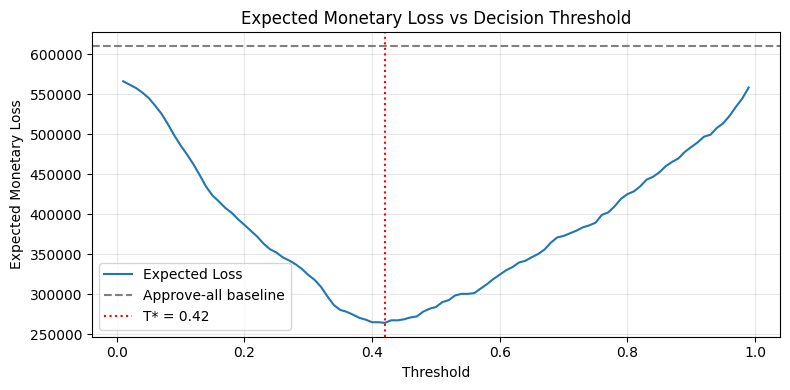

In [14]:
# Loss vs Threshold curve (deliverable)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, losses, label="Expected Loss")
ax.axhline(baseline_loss, color="gray", linestyle="--", label="Approve-all baseline")
ax.axvline(best_threshold, color="red", linestyle=":", label=f"T* = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected Monetary Loss")
ax.set_title("Expected Monetary Loss vs Decision Threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion:** Primary metric is Expected Monetary Loss. Expected Loss Reduction = baseline_loss - best_loss; relative reduction as above. T* minimizes loss on validation under the defined cost matrix.

---
## 5. Operational Metrics at Optimal Threshold

**Goal:** Evaluate Recall, FPR and ReviewRate at T*; verify threshold respects operational constraints.

In [ ]:
# Compute confusion matrix and derived metrics at best_threshold

best_pred = (val_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_val, best_pred)
TN, FP, FN, TP = cm.ravel()

Recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # fraction of fraud detected
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0  # False Positive Rate

# In this baseline we use only approve vs block (no separate review band)
ReviewRate = 0.0

best_loss, baseline_loss, Recall, FPR, ReviewRate

**Operational constraints:** FPR and flag rate should be acceptable; ReviewRate < 5% when a review band exists (this baseline is two-way only, so ReviewRate = 0).

**Conclusion:** At T*, Recall and FPR are reported above. Threshold is chosen by cost minimization; no FPR cap enforced here. Future work can add constraints and re-optimize.

---
## 6. Interpretability and Model Diagnostics

**Goal:** Inspect coefficients, identify top drivers, discuss bias–variance and baseline limitations.

In [16]:
# Extract coefficients
clf = baseline_pipeline.named_steps["clf"]
scaler = baseline_pipeline.named_steps["scaler"]

coefs = clf.coef_[0]
feature_names = numeric_cols

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).sort_values("coef", ascending=False)

coef_df.head(10), coef_df.tail(10)

(    feature      coef
 19      C11  7.647303
 12       C4  3.594045
 16       C8  1.725691
 17       C9  1.326566
 375    V338  1.085408
 224    V187  0.995902
 226    V189  0.772883
 237    V200  0.735337
 204    V167  0.723175
 284    V247  0.720185,
     feature      coef
 10       C2 -1.026963
 9        C1 -1.144535
 369    V332 -1.181957
 240    V203 -1.287335
 205    V168 -1.461704
 20      C12 -1.555989
 278    V241 -1.643287
 14       C6 -1.671170
 15       C7 -1.840602
 22      C14 -7.154628)

**Bias–variance:** Logistic regression has high bias (linear boundary) and low variance; it may underfit but remains interpretable. More complex models will be evaluated using the same Expected Monetary Loss.

**Conclusion:** Coefficients show main drivers. Baseline is intentionally simple; any future model must be compared on cost-based metrics, not only AUC.

In [ ]:
# Numerical summary (key results for docs/05_modeling_strategy.md)
summary = pd.DataFrame({
    "Metric": [
        "baseline_loss (approve-all)",
        "best_loss (at T*)",
        "T*",
        "Expected Loss Reduction (abs)",
        "Expected Loss Reduction (rel)",
        "Recall @ T*",
        "FPR @ T*",
    ],
    "Value": [
        baseline_loss,
        best_loss,
        best_threshold,
        baseline_loss - best_loss,
        (baseline_loss - best_loss) / baseline_loss,
        Recall,
        FPR,
    ],
})
summary

---
## 7. Summary and Next Steps

**Key results:** See the numerical summary table below. Primary metric: Expected Monetary Loss; T* by cost minimization; savings vs approve-all quantified.

**Next steps:** Calibration curve and recalibration if needed; feature/regularization experiments; three-way policy with ReviewRate constraint; document in `docs/05_modeling_strategy.md`.

This baseline marks the transition from system design to cost-sensitive modeling with measurable financial impact.